# 🏠 Previsão de Preços de Imóveis no Airbnb — Sydney, Austrália
## SME0828 — Introdução à Ciência de Dados | ICMC-USP
### Prof. Francisco Rodrigues

---

**Objetivo:** Construir um modelo de regressão para prever o preço por noite de imóveis listados no Airbnb na cidade de Sydney.

**Pipeline completo:**
1. Obtenção dos dados
2. Limpeza dos dados
3. Estatística descritiva e Análise Exploratória (EDA)
4. Divisão treino/teste estratificada
5. Engenharia de atributos
6. Pipeline de pré-processamento
7. Modelos supervisionados com ajuste de hiperparâmetros
8. Regularização (Ridge, Lasso, Elastic Net)
9. Comparação final via validação cruzada
10. Avaliação no conjunto de teste
11. Importância das variáveis
12. Aplicação prática — estimação de preço justo para Bondi Beach

---
# Importação de Bibliotecas

In [70]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedShuffleSplit,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

# Configurações visuais
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 35)
pd.set_option('display.width', 120)


---
## 1. Obtenção dos Dados

In [71]:
GITHUB_URL = (
    "https://raw.githubusercontent.com/Finance-781/FinML/master/"
    "Lecture%202%20-%20End-to-End%20ML%20Project%20/Practice/datasets/"
    "sydney_airbnb.csv"
)

df_raw = pd.read_csv(GITHUB_URL)
print(f"Dataset carregado: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas")
df_raw.head()

Dataset carregado: 27070 linhas × 84 colunas


,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,picture_url,host_id,host_url,host_name,host_since,...,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,11156,https://www.airbnb.com/rooms/11156,An Oasis in the City,Very central to the city which can be reached ...,Potts Pt. is a vibrant and popular inner-city...,Very central to the city which can be reached ...,"It is very close to everything and everywhere,...","$150.00 key security deposit, refundable on re...",It is 7 minutes walk to the Kings Cross.train ...,Kitchen & laundry facilities. Shared bathroom.,As much as they want.,Be considerate. No showering after 2330h.,https://a0.muscache.com/im/pictures/2797669/17...,40855,https://www.airbnb.com/users/show/40855,Colleen,23/09/09,...,339,177,5/12/09,1/07/18,92.0,9.0,9.0,10.0,10.0,10.0,9.0,f,moderate,f,f,1,1.69
1,12351,https://www.airbnb.com/rooms/12351,Sydney City & Harbour at the door,Come stay with Vinh & Stuart (Awarded as one o...,"We're pretty relaxed hosts, and we fully appre...",Come stay with Vinh & Stuart (Awarded as one o...,"Pyrmont is an inner-city village of Sydney, on...",We've a few reasons for the 6.00pm arrival tim...,Our home is centrally located and an easy walk...,We look forward to welcoming you just as we wo...,As much or as little as you like. We live here...,We look forward to welcoming you to stay you j...,https://a0.muscache.com/im/pictures/763ad5c8-c...,17061,https://www.airbnb.com/users/show/17061,Stuart,14/05/09,...,188,468,24/07/10,27/06/18,95.0,10.0,9.0,10.0,10.0,10.0,10.0,f,strict_14_with_grace_period,t,t,2,4.83
2,14250,https://www.airbnb.com/rooms/14250,Manly Harbour House,"Beautifully renovated, spacious and quiet, our...",Our home is a thirty minute walk along the sea...,"Beautifully renovated, spacious and quiet, our...",Balgowlah Heights is one of the most prestigio...,NaN,Balgowlah - Manly bus # 131 or #132 (Bus stop...,Guests have access to whole house except locke...,NaN,Standard Terms and Conditions of Temporary Hol...,https://a0.muscache.com/im/pictures/56935671/f...,55948,https://www.airbnb.com/users/show/55948,Heidi,20/11/09,...,168,1,2/01/16,2/01/16,100.0,10.0,10.0,10.0,8.0,10.0,10.0,f,strict_14_with_grace_period,f,f,2,0.03
3,14935,https://www.airbnb.com/rooms/14935,Eco-conscious Travellers: Private Room,Welcome! This apartment will suit a short term...,I live upstairs in my own room with my own bat...,Welcome! This apartment will suit a short term...,NaN,"The building can be hard to find, so please en...",DIRECTIONS VIA TAXI: Get dropped off at Renwic...,"I work from home most times - so if I'm home, ...","I'm not a big chatter, so don't get offended i...",1. Enjoy and always bring a smile during your ...,https://a0.muscache.com/im/pictures/2257353/d3...,58796,https://www.airbnb.com/users/show/58796,Kevin,30/11/09,...,215,172,28/11/11,26/06/18,89.0,9.0,8.0,9.0,10.0,9.0,9.0,f,moderate,f,f,2,2.14
4,14974,https://www.airbnb.com/rooms/14974,Eco-conscious Traveller: Sofa Couch,Welcome! This apartment will suit a short term...,Comes with a fully equipped gym and pool - whi...,Welcome! This apartment will suit a short term...,NaN,I live upstairs in my own room with my own bat...,DIRECTIONS VIA TAXI: Get dropped off at Renwic...,"I work from home most times - so if I'm home, ...","I'm not a big chatter, so don't get offended i...",1. Enjoy and always bring a smile during your ...,https://a0.muscache.com/im/pictures/2197966/6e...,58796,https://www.airbnb.com/users/show/58796,Kevin,30/11/09,...,287,147,23/09/11,2/07/18,90.0,9.0,8.0,9.0,9.0,9.0,9.0,f,moderate,f,f,2,1.78


In [72]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 27070 entries, 0 to 27069
Data columns (total 84 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                27070 non-null  int64  
 1   listing_url                       27070 non-null  str    
 2   name                              27056 non-null  str    
 3   summary                           26765 non-null  str    
 4   space                             18808 non-null  str    
 5   description                       27045 non-null  str    
 6   neighborhood_overview             16114 non-null  str    
 7   notes                             11404 non-null  str    
 8   transit                           16863 non-null  str    
 9   access                            16666 non-null  str    
 10  interaction                       15306 non-null  str    
 11  house_rules                       16456 non-null  str    
 12  picture_url    

---
## 2. Limpeza dos Dados

### 2.1 Seleção de colunas relevantes

As colunas presentes no exemplos serão analisádas

In [73]:
# Colunas que serão utilizadas na análise
colunas_selecionadas = [
    "price", "city", "longitude", "latitude", "review_scores_rating",
    "number_of_reviews", "minimum_nights", "security_deposit", "cleaning_fee",
    "accommodates", "bathrooms", "bedrooms", "beds", "property_type",
    "room_type", "availability_365", "host_identity_verified",
    "host_is_superhost", "host_since", "cancellation_policy"
]

df = df_raw[colunas_selecionadas].copy()

print(f"Colunas selecionadas: {df.shape[1]}")
print(f"Linhas: {df.shape[0]}")

Colunas selecionadas: 20
Linhas: 27070


### 2.2 Conversão de tipos

Colunas como `price`, `security_deposit`, `cleaning_fee` e `extra_people` estão no formato string (e.g., `"$65.00"`). Vamos convertê-las para numérico. Colunas booleanas precisam mudar de 't' e 'f' para 1 e 0.

In [74]:
def limpar_moeda(col):
    """Remove $, vírgulas e espaços, converte para float."""
    return (col
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
            .replace('nan', np.nan)
            .astype(float))

# Conversão dos valores monetários
for col in ['price','cleaning_fee','security_deposit']:
    df[col] = limpar_moeda(df[col])

# Converter host_since para datetime e extrair a antiguidade em dias
df['host_since'] = pd.to_datetime(df['host_since'], format='mixed', dayfirst=True)
data_ref = df['host_since'].max()  # data de referência
df['host_since_days'] = (data_ref - df['host_since']).dt.days

# Converter booleanos t/f para 0/1 de forma segura (preserva 0 e 1 se reexecutado)
for col in ['host_is_superhost', 'host_identity_verified']:
    df[col] = df[col].map({'t': 1, 'f': 0, 1: 1, 0: 0, True: 1, False: 0})

print("✅ Conversões de tipo concluídas")
print(f"\nPrice — min: {df['price'].min()}, max: {df['price'].max()}, mediana: {df['price'].median()}")
df[['price', 'security_deposit', 'cleaning_fee']].describe()

✅ Conversões de tipo concluídas

Price — min: 0.0, max: 12999.0, mediana: 135.0


,price,security_deposit,cleaning_fee
count,27070.000000,16722.000000,19250.000000
mean,209.278796,494.982897,93.759481
std,304.336271,687.542775,91.713666
min,0.000000,0.000000,0.000000
25%,80.000000,150.000000,35.000000
50%,135.000000,300.000000,70.000000
75%,229.000000,500.000000,120.000000
max,12999.000000,7000.000000,999.000000


### 2.3 Tratamento de valores ausentes

In [75]:
# Verificar nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, '%': nulos_pct}).query('Nulos > 0').sort_values('%', ascending=False)
print("Colunas com valores ausentes:")
print(nulos_df.to_string())

Colunas com valores ausentes:
                        Nulos      %
security_deposit        10348  38.23
cleaning_fee             7820  28.89
review_scores_rating     7558  27.92
host_since_days            35   0.13
host_since                 35   0.13
host_is_superhost          35   0.13
host_identity_verified     35   0.13
city                       33   0.12
beds                       33   0.12
bathrooms                  22   0.08
bedrooms                    8   0.03


In [76]:
# Remover linhas onde o preço (target) é nulo ou zero
print(f"Antes: {len(df)} linhas")
df = df[df['price'].notna() & (df['price'] > 0)].copy()
print(f"Após remover price nulo/zero: {len(df)} linhas")

# Preencher taxas monetárias com 0 (sem taxa = $0)
df['security_deposit'] = df['security_deposit'].fillna(0)
df['cleaning_fee'] = df['cleaning_fee'].fillna(0)

# Preencher booleanos com 0 
for col in ['host_is_superhost', 'host_identity_verified']:
    df[col] = df[col].fillna(0).astype(int)

print("\n✅ Valores ausentes tratados (restantes serão imputados no pipeline)")
print(df.isnull().sum()[df.isnull().sum() > 0])

Antes: 27070 linhas
Após remover price nulo/zero: 27060 linhas

✅ Valores ausentes tratados (restantes serão imputados no pipeline)
city                      33
review_scores_rating    7553
bathrooms                 22
bedrooms                   8
beds                      33
host_since                35
host_since_days           35
dtype: int64


### 2.4 Tratamento de outliers no preço

Preços extremamente altos ou baixos podem distorcer o modelo. Vamos analisar a distribuição.

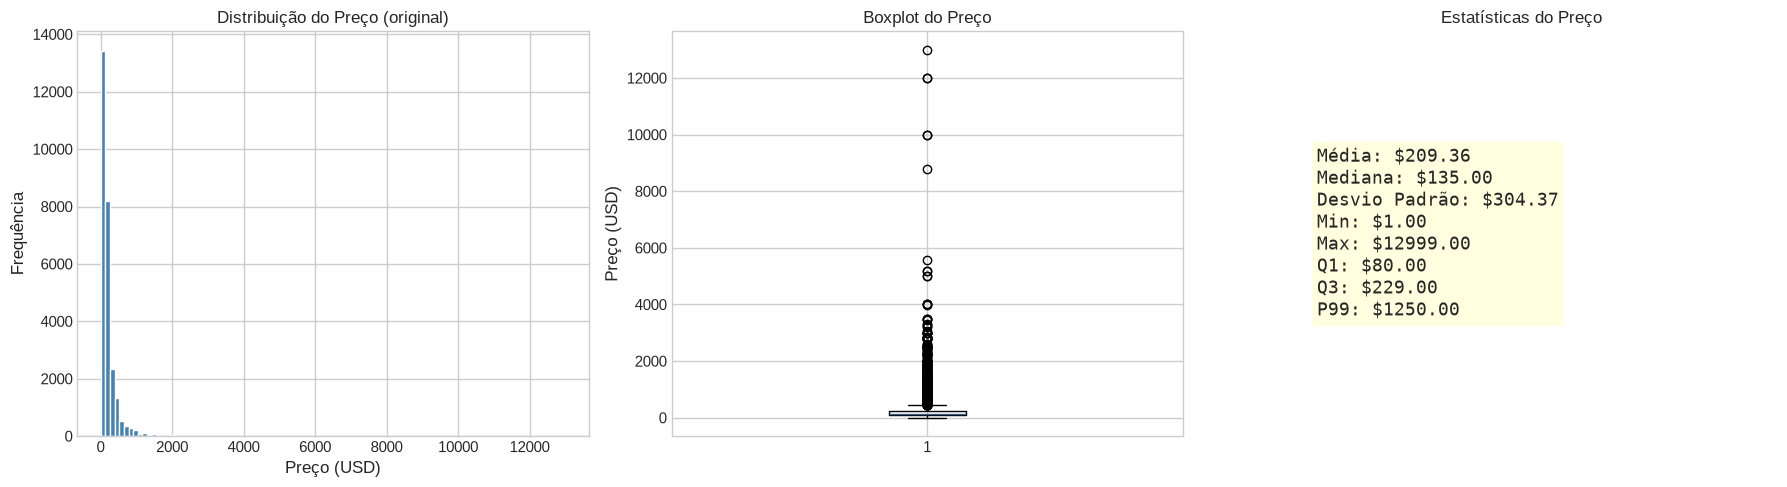

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma original
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Preço (original)')
axes[0].set_xlabel('Preço (USD)')
axes[0].set_ylabel('Frequência')

# Boxplot
axes[1].boxplot(df['price'], vert=True)
axes[1].set_title('Boxplot do Preço')
axes[1].set_ylabel('Preço (USD)')

# Estatísticas
stats_text = (
    f"Média: ${df['price'].mean():.2f}\n"
    f"Mediana: ${df['price'].median():.2f}\n"
    f"Desvio Padrão: ${df['price'].std():.2f}\n"
    f"Min: ${df['price'].min():.2f}\n"
    f"Max: ${df['price'].max():.2f}\n"
    f"Q1: ${df['price'].quantile(0.25):.2f}\n"
    f"Q3: ${df['price'].quantile(0.75):.2f}\n"
    f"P99: ${df['price'].quantile(0.99):.2f}"
)
axes[2].text(0.1, 0.5, stats_text, fontsize=13, family='monospace',
             verticalalignment='center', transform=axes[2].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[2].set_title('Estatísticas do Preço')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Limites de corte: $28.00 — $1600.00
Removidos 250 outliers (0.92%)
Dataset final: 26810 linhas


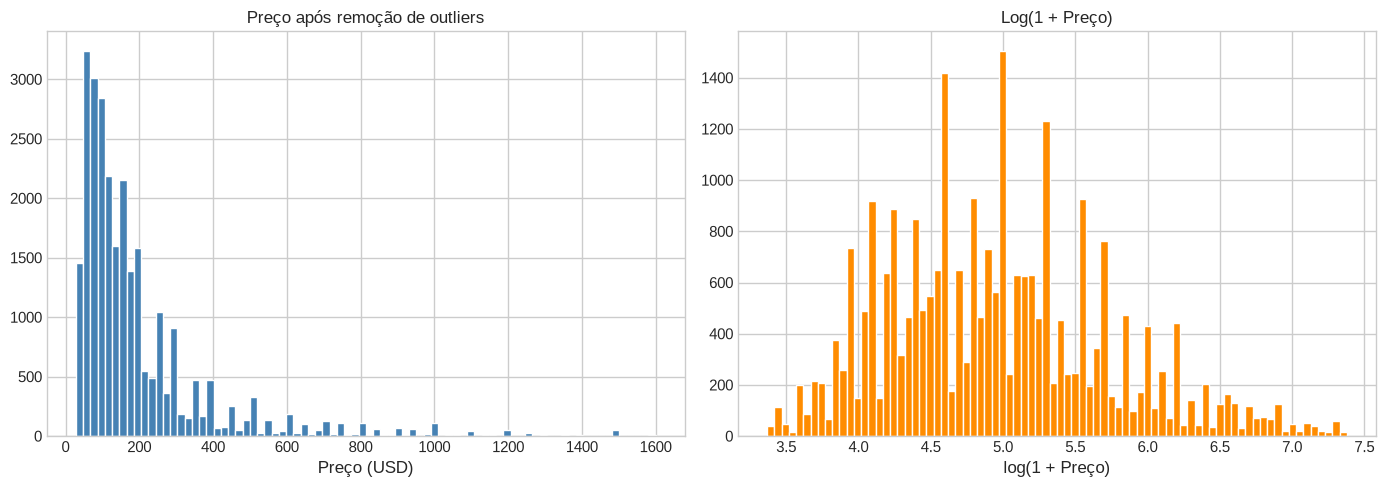

In [78]:
# Remover outliers extremos: manter entre percentil 1 e 99
q_low = df['price'].quantile(0.005)
q_high = df['price'].quantile(0.995)
print(f"Limites de corte: ${q_low:.2f} — ${q_high:.2f}")

antes = len(df)
df = df[(df['price'] >= q_low) & (df['price'] <= q_high)].copy()
print(f"Removidos {antes - len(df)} outliers ({(antes - len(df))/antes*100:.2f}%)")
print(f"Dataset final: {len(df)} linhas")

# Histograma após remoção de outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Preço após remoção de outliers')
axes[0].set_xlabel('Preço (USD)')

# Log do preço
axes[1].hist(np.log1p(df['price']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Log(1 + Preço)')
axes[1].set_xlabel('log(1 + Preço)')

plt.tight_layout()
plt.show()

---
## 3. Estatística Descritiva e Análise Exploratória (EDA)

### 3.1 Estatísticas descritivas

In [79]:
df.describe().round(2)

,price,longitude,latitude,review_scores_rating,number_of_reviews,minimum_nights,security_deposit,cleaning_fee,accommodates,bathrooms,bedrooms,beds,availability_365,host_identity_verified,host_is_superhost,host_since,host_since_days
count,26810.00,26810.00,26810.00,19400.00,26810.00,26810.00,26810.00,26810.00,26810.00,26788.00,26802.00,26779.00,26810.00,26810.00,26810.00,26776,26776.00
mean,197.15,151.21,-33.86,93.42,14.10,4.48,295.16,65.55,3.37,1.34,1.60,2.00,101.72,0.47,0.13,2015-02-13 03:45:55.661786,1064.84
min,28.00,150.64,-34.14,20.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2009-02-22 00:00:00,0.00
25%,80.00,151.18,-33.90,90.00,1.00,1.00,0.00,0.00,2.00,1.00,1.00,1.00,0.00,0.00,0.00,2014-01-11 18:00:00,634.00
50%,135.00,151.22,-33.88,96.00,3.00,2.00,0.00,40.00,2.00,1.00,1.00,1.00,32.00,0.00,0.00,2015-04-04 00:00:00,1015.00
75%,225.00,151.26,-33.83,100.00,13.00,5.00,400.00,99.00,4.00,1.50,2.00,2.00,179.00,1.00,0.00,2016-04-19 00:00:00,1462.25
max,1600.00,151.34,-33.39,100.00,468.00,1000.00,7000.00,999.00,16.00,10.00,46.00,29.00,365.00,1.00,1.00,2018-01-13 00:00:00,3247.00
std,200.82,0.08,0.07,9.35,29.91,14.44,550.89,85.07,2.16,0.64,1.09,1.51,127.88,0.50,0.33,NaN,594.88


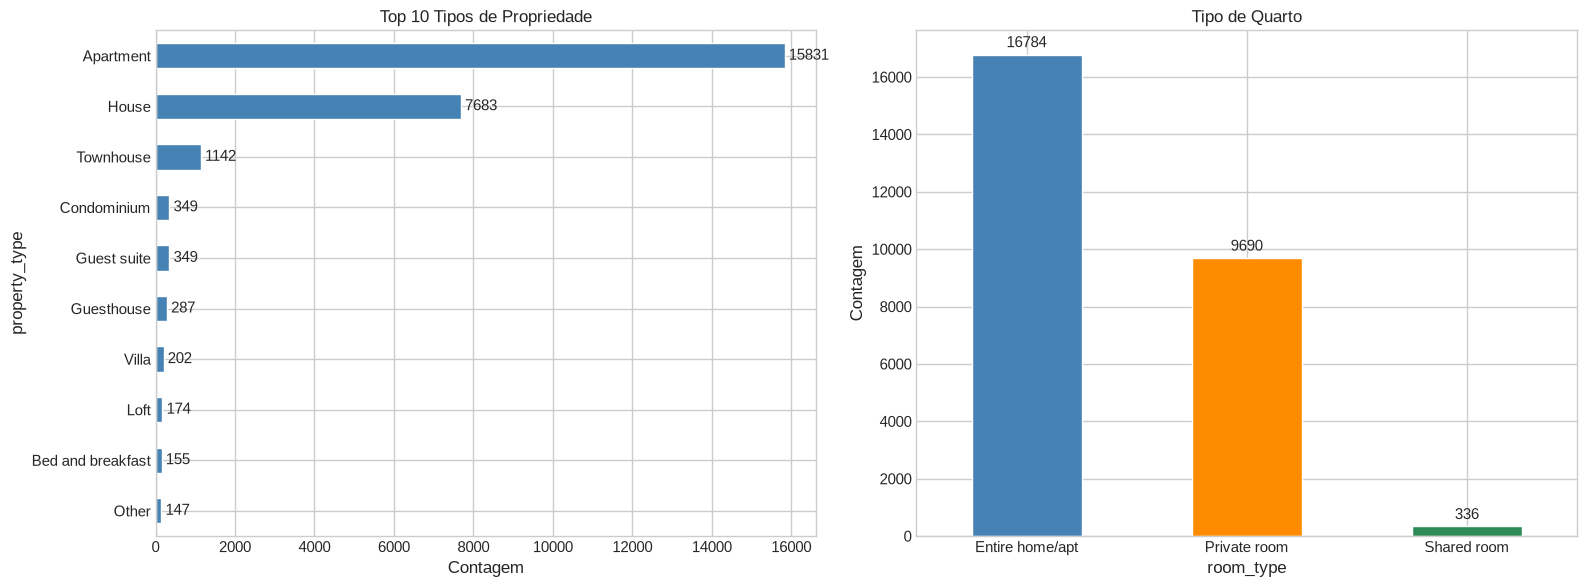

In [80]:
# Distribuição dos tipos de propriedade mais comuns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 property types
prop_counts = df['property_type'].value_counts().head(10)
prop_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set_title('Top 10 Tipos de Propriedade')
axes[0].set_xlabel('Contagem')
axes[0].invert_yaxis()

# Room type
room_counts = df['room_type'].value_counts()
room_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange', 'seagreen'], rot=0)
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].set_title('Tipo de Quarto')
axes[1].set_ylabel('Contagem')

plt.tight_layout()
plt.show()

### 3.2 Correlações entre variáveis numéricas

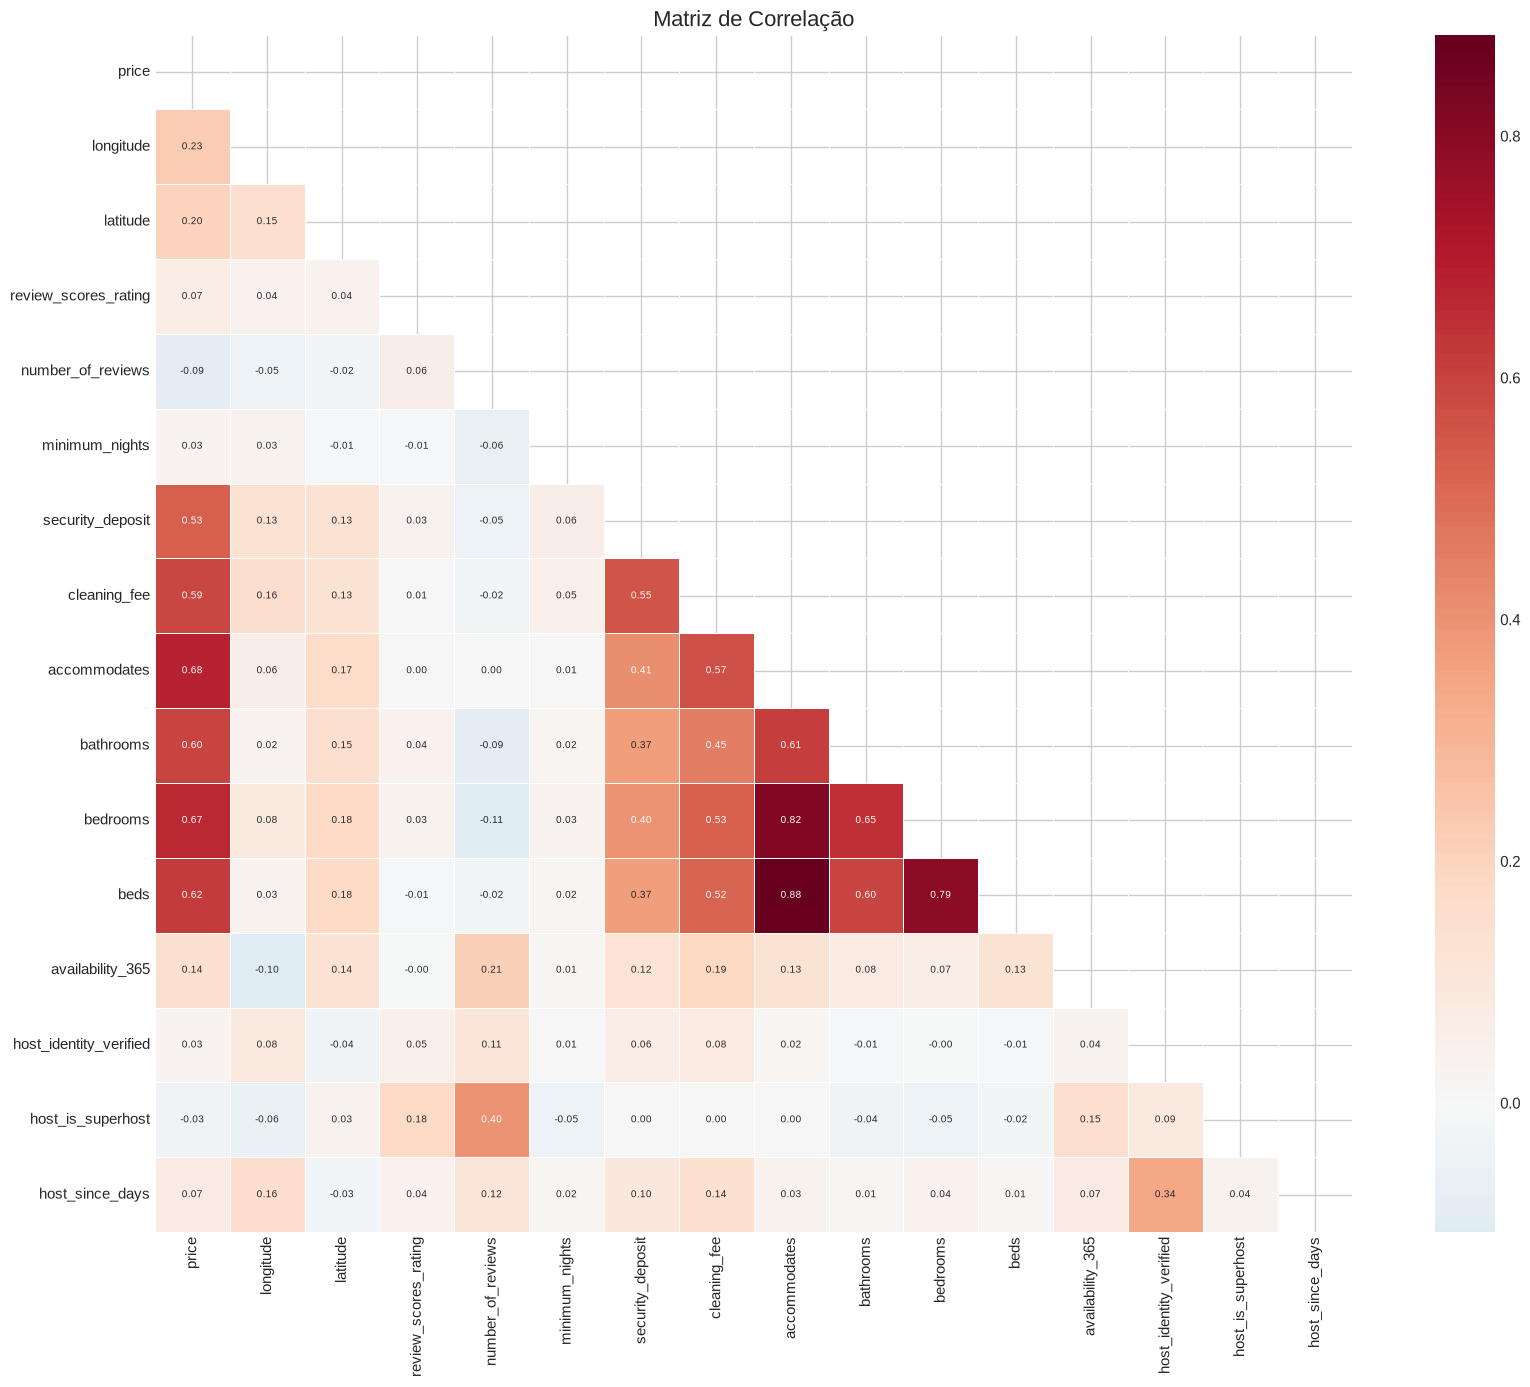

In [81]:
# Selecionar colunas numéricas para correlação
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 7})
plt.title('Matriz de Correlação', fontsize=16)
plt.tight_layout()
plt.show()

Top correlações com price:
accommodates              0.678
bedrooms                  0.667
beds                      0.617
bathrooms                 0.601
cleaning_fee              0.587
security_deposit          0.528
longitude                 0.229
latitude                  0.203
availability_365          0.144
host_since_days           0.073
review_scores_rating      0.067
minimum_nights            0.027
host_identity_verified    0.026
host_is_superhost        -0.035
number_of_reviews        -0.093


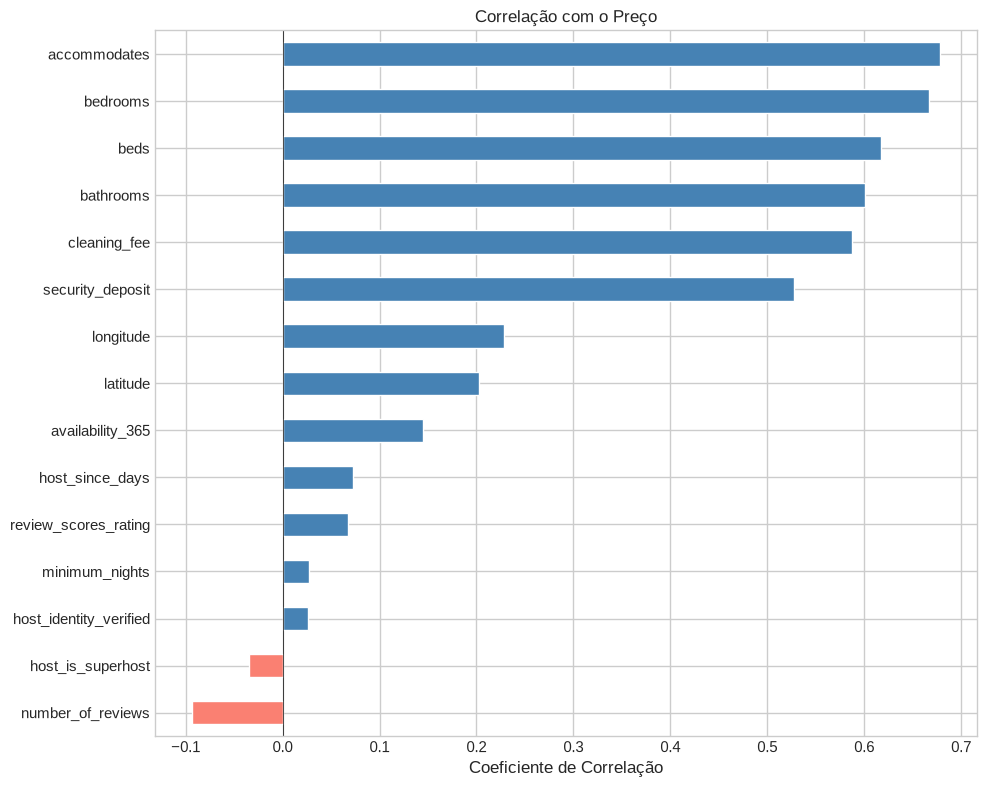

In [82]:
# Correlações com o preço (top features)
corr_price = corr['price'].drop('price').sort_values(ascending=False)
print("Top correlações com price:")
print(corr_price.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
corr_price.plot(kind='barh', color=corr_price.apply(
    lambda x: 'steelblue' if x > 0 else 'salmon'), ax=ax)
ax.set_title('Correlação com o Preço')
ax.set_xlabel('Coeficiente de Correlação')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.3 Histogramas

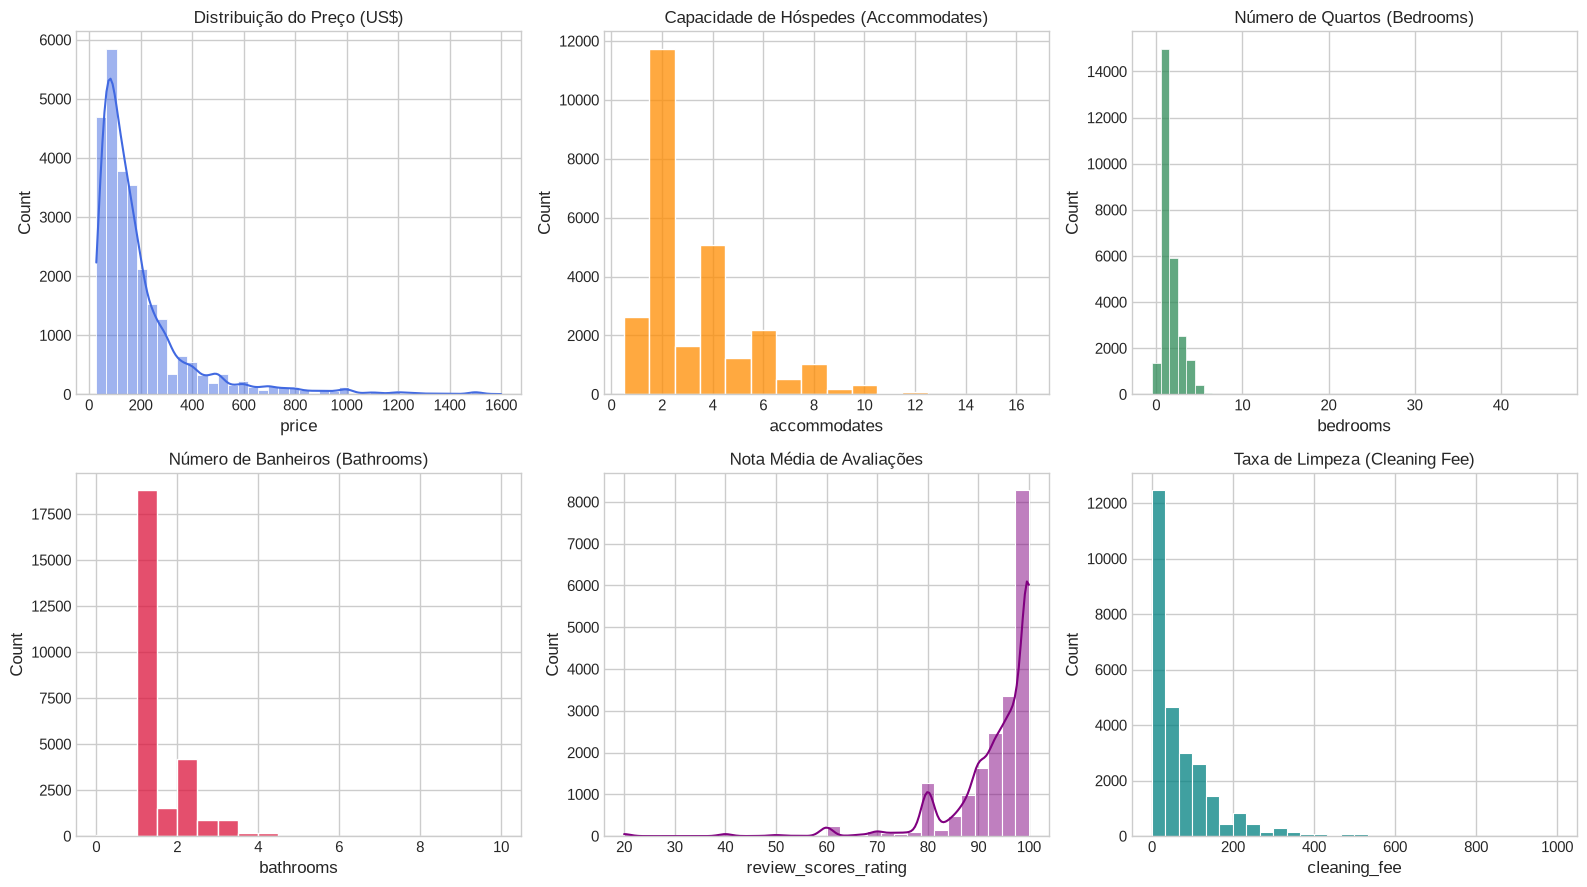

In [83]:
# Distribuição das principais variáveis preditoras e do preço
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['price'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title("Distribuição do Preço (US$)")

sns.histplot(df['accommodates'], discrete=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title("Capacidade de Hóspedes (Accommodates)")

sns.histplot(df['bedrooms'].dropna(), discrete=True, ax=axes[0, 2], color='seagreen')
axes[0, 2].set_title("Número de Quartos (Bedrooms)")

sns.histplot(df['bathrooms'].dropna(), bins=20, ax=axes[1, 0], color='crimson')
axes[1, 0].set_title("Número de Banheiros (Bathrooms)")

sns.histplot(df['review_scores_rating'].dropna(), bins=30, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title("Nota Média de Avaliações")

sns.histplot(df['cleaning_fee'], bins=30, ax=axes[1, 2], color='teal')
axes[1, 2].set_title("Taxa de Limpeza (Cleaning Fee)")

plt.tight_layout()
plt.show()


### 3.4 Mapa geográfico dos imóveis

Mapa com as localizações e preços de imóveis

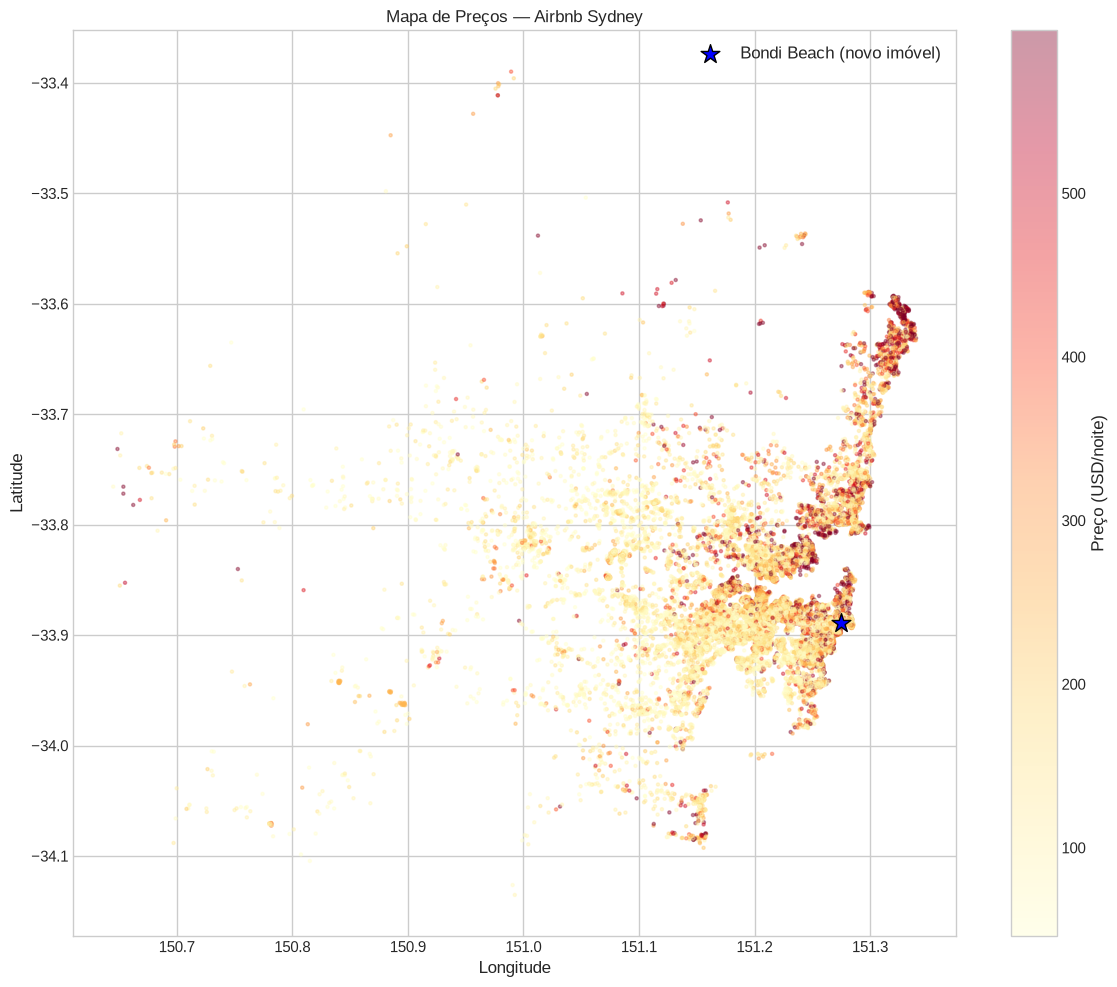

In [84]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['price'], cmap='YlOrRd',
    s=5, alpha=0.4,
    vmin=df['price'].quantile(0.05),
    vmax=df['price'].quantile(0.95)
)
plt.colorbar(scatter, ax=ax, label='Preço (USD/noite)')

# Marcar Bondi Beach
ax.scatter(151.274506, -33.889087, c='blue', s=200, marker='*',
           edgecolors='black', linewidths=1, zorder=5, label='Bondi Beach (novo imóvel)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mapa de Preços — Airbnb Sydney')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Divisão Treino/Teste Estratificada

Antes de qualquer decisão de modelagem, separamos os dados. Usamos estratificação pela faixa de preço para manter a distribuição proporcional.

In [85]:
# Criar faixas de preço para estratificação
df['price_cat'] = pd.cut(
    df['price'],
    bins=[0, 50, 100, 150, 200, 300, np.inf],
    labels=[1, 2, 3, 4, 5, 6]
)

print("Distribuição das faixas de preço:")
print(df['price_cat'].value_counts().sort_index())

# Divisão estratificada 80/20
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(df, df['price_cat']):
    train_set = df.iloc[train_idx].copy()
    test_set = df.iloc[test_idx].copy()

# Remover coluna auxiliar
for s in [train_set, test_set]:
    s.drop('price_cat', axis=1, inplace=True)
df.drop('price_cat', axis=1, inplace=True)

print(f"\nTreino: {len(train_set)} amostras")
print(f"Teste:  {len(test_set)} amostras")
print(f"Proporção teste: {len(test_set) / len(df) * 100:.1f}%")

Distribuição das faixas de preço:
price_cat
1    2282
2    8036
3    5311
4    3798
5    3367
6    4016
Name: count, dtype: int64

Treino: 21448 amostras
Teste:  5362 amostras
Proporção teste: 20.0%


---
## 5. Engenharia de Atributos

### Análise crítica e criação de variáveis

**Variáveis criadas:**
- `host_since_days`: antiguidade do anfitrião (já criada)

**Variáveis removidas:**
- `host_since`: data original (já convertida para `host_since_days`)
- `city`: Muitos valores possíveis. A informação geográfica já está capturada por `latitude` e `longitude`

**Variáveis alteradas:**
- `property_type`: Agrupamento de tipos raros em uma categoria 'Other'

In [86]:
# Identificar tipos mais comuns de propriedade no treino
top_property_types = train_set['property_type'].value_counts()
top_property_types = top_property_types[top_property_types >= 100].index.tolist()

def engenharia_atributos(data):
    """Aplica engenharia de atributos ao dataframe."""
    df_eng = data.copy()

    df_eng = df_eng.drop(columns=['city','host_since'])

    # Simplificar property_type (agrupar tipos raros em 'Other')
    df_eng['property_type'] = df_eng['property_type'].apply(
        lambda x: x if x in top_property_types else 'Other'
    )

    return df_eng

# Aplicar nos conjuntos de treino e teste
train = engenharia_atributos(train_set)
test = engenharia_atributos(test_set)

print(f"Features após engenharia: {train.shape[1] - 1}")  # -1 pelo target
print(f"\nColunas finais:")
print(list(train.columns))

Features após engenharia: 18

Colunas finais:
['price', 'longitude', 'latitude', 'review_scores_rating', 'number_of_reviews', 'minimum_nights', 'security_deposit', 'cleaning_fee', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'property_type', 'room_type', 'availability_365', 'host_identity_verified', 'host_is_superhost', 'cancellation_policy', 'host_since_days']


### 5.1 Verificação das features finais

In [87]:
# Separar features e target
X_train = train.drop('price', axis=1)
y_train = train['price'].copy()

X_test = test.drop('price', axis=1)
y_test = test['price'].copy()

# Identificar colunas numéricas e categóricas
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Features numéricas ({len(num_features)}): {num_features}")
print(f"\nFeatures categóricas ({len(cat_features)}): {cat_features}")
print(f"\nTarget: price")
print(f"\nNulos no treino:\n{X_train.isnull().sum()[X_train.isnull().sum() > 0]}")

Features numéricas (15): ['longitude', 'latitude', 'review_scores_rating', 'number_of_reviews', 'minimum_nights', 'security_deposit', 'cleaning_fee', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_365', 'host_identity_verified', 'host_is_superhost', 'host_since_days']

Features categóricas (3): ['property_type', 'room_type', 'cancellation_policy']

Target: price

Nulos no treino:
review_scores_rating    5874
bathrooms                 16
bedrooms                   6
beds                      26
host_since_days           30
dtype: int64


---
## 6. Pipeline de Pré-processamento

Criamos um pipeline com:
- **Numéricas:** imputação pela mediana → padronização (StandardScaler)
- **Categóricas:** imputação pela moda → One-Hot Encoding

In [88]:
# Pipeline para features numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Pipeline para features categóricas
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combinar pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

# Verificar transformação
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Nomes das features transformadas
cat_encoded_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_encoded_names

print(f"Shape treino transformado: {X_train_prep.shape}")
print(f"Shape teste transformado: {X_test_prep.shape}")
print(f"\nTotal de features (após encoding): {len(all_feature_names)}")

Shape treino transformado: (21448, 33)
Shape teste transformado: (5362, 33)

Total de features (após encoding): 33


---
## 7. Modelos Supervisionados com Ajuste de Hiperparâmetros

### 7.1 Modelo Baseline — Regressão Linear

In [89]:
# Regressão Linear (baseline)
lr = LinearRegression()
lr_cv_mae = cross_val_score(lr, X_train_prep, y_train, cv=5,
                             scoring='neg_mean_absolute_error')
lr_cv_rmse = cross_val_score(lr, X_train_prep, y_train, cv=5,
                              scoring='neg_root_mean_squared_error')
lr_cv_r2 = cross_val_score(lr, X_train_prep, y_train, cv=5, scoring='r2')

# Treinar no conjunto completo para uso posterior
lr.fit(X_train_prep, y_train)

print("=" * 60)
print("REGRESSÃO LINEAR (Baseline)")
print("=" * 60)
print(f"MAE  (CV 5-fold): {-lr_cv_mae.mean():.2f} ± {lr_cv_mae.std():.2f}")
print(f"RMSE (CV 5-fold): {-lr_cv_rmse.mean():.2f} ± {lr_cv_rmse.std():.2f}")
print(f"R²   (CV 5-fold): {lr_cv_r2.mean():.4f} ± {lr_cv_r2.std():.4f}")

REGRESSÃO LINEAR (Baseline)
MAE  (CV 5-fold): 74.09 ± 0.45
RMSE (CV 5-fold): 120.41 ± 1.68
R²   (CV 5-fold): 0.6372 ± 0.0154


### 7.2 Árvore de Decisão com GridSearchCV

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
}

grid_dt = GridSearchCV(
    dt, param_grid_dt, cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=1, verbose=1        
)
grid_dt.fit(X_train_prep, y_train)

best_dt = grid_dt.best_estimator_

# Extrair RMSE e R² do melhor estimador via CV (reutilizando os dados já treinados)
dt_cv_rmse = cross_val_score(best_dt, X_train_prep, y_train, cv=5,
                              scoring='neg_root_mean_squared_error')
dt_cv_r2 = cross_val_score(best_dt, X_train_prep, y_train, cv=5, scoring='r2')

print("\n" + "=" * 60)
print("ÁRVORE DE DECISÃO — GridSearchCV")
print("=" * 60)
print(f"Melhores parâmetros: {grid_dt.best_params_}")
print(f"MAE  (melhor CV):  {-grid_dt.best_score_:.2f}")
print(f"RMSE (CV 5-fold):  {-dt_cv_rmse.mean():.2f} ± {dt_cv_rmse.std():.2f}")
print(f"R²   (CV 5-fold):  {dt_cv_r2.mean():.4f} ± {dt_cv_r2.std():.4f}")

# Liberar resultado intermediário
del grid_dt; gc.collect()

Fitting 5 folds for each of 80 candidates, totalling 400 fits

ÁRVORE DE DECISÃO — GridSearchCV
Melhores parâmetros: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
MAE  (melhor CV):  67.04
RMSE (CV 5-fold):  119.93 ± 3.74
R²   (CV 5-fold):  0.6393 ± 0.0318


66401

### 7.3 Floresta Aleatória com RandomizedSearchCV

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

random_rf = RandomizedSearchCV(
    rf, param_dist_rf, n_iter=15, cv=5,  
    scoring='neg_mean_absolute_error',
    n_jobs=1, random_state=42, verbose=1  
)
random_rf.fit(X_train_prep, y_train)

best_rf = random_rf.best_estimator_

rf_cv_rmse = cross_val_score(best_rf, X_train_prep, y_train, cv=5,
                              scoring='neg_root_mean_squared_error')
rf_cv_r2 = cross_val_score(best_rf, X_train_prep, y_train, cv=5, scoring='r2')

print("\n" + "=" * 60)
print("FLORESTA ALEATÓRIA — RandomizedSearchCV")
print("=" * 60)
print(f"Melhores parâmetros: {random_rf.best_params_}")
print(f"MAE  (melhor CV):  {-random_rf.best_score_:.2f}")
print(f"RMSE (CV 5-fold):  {-rf_cv_rmse.mean():.2f} ± {rf_cv_rmse.std():.2f}")
print(f"R²   (CV 5-fold):  {rf_cv_r2.mean():.4f} ± {rf_cv_r2.std():.4f}")

# Liberar resultado intermediário
del random_rf; gc.collect()

Fitting 5 folds for each of 15 candidates, totalling 75 fits

FLORESTA ALEATÓRIA — RandomizedSearchCV
Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
MAE  (melhor CV):  60.33
RMSE (CV 5-fold):  106.61 ± 1.40
R²   (CV 5-fold):  0.7154 ± 0.0155


335

---
## 8 Regularização

---
### 8.1. Ridge (L2)

In [92]:
# ===== Ridge (L2) =====
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]}

grid_ridge = GridSearchCV(
    Ridge(), param_grid_ridge, cv=5,
    scoring='neg_mean_absolute_error', n_jobs=1
)
grid_ridge.fit(X_train_prep, y_train)

best_ridge = grid_ridge.best_estimator_
ridge_cv_mae = -grid_ridge.best_score_
ridge_cv_rmse_arr = cross_val_score(best_ridge, X_train_prep, y_train, cv=5,
                                     scoring='neg_root_mean_squared_error')
ridge_cv_r2_arr = cross_val_score(best_ridge, X_train_prep, y_train, cv=5, scoring='r2')

print("=" * 60)
print("RIDGE (L2)")
print("=" * 60)
print(f"Melhor alpha:      {grid_ridge.best_params_['alpha']}")
print(f"MAE  (CV 5-fold):  {ridge_cv_mae:.2f}")
print(f"RMSE (CV 5-fold):  {-ridge_cv_rmse_arr.mean():.2f} ± {ridge_cv_rmse_arr.std():.2f}")
print(f"R²   (CV 5-fold):  {ridge_cv_r2_arr.mean():.4f} ± {ridge_cv_r2_arr.std():.4f}")

del grid_ridge; gc.collect()

RIDGE (L2)
Melhor alpha:      1000
MAE  (CV 5-fold):  73.43
RMSE (CV 5-fold):  120.59 ± 1.78
R²   (CV 5-fold):  0.6361 ± 0.0144


111

---
### 8.2. Lasso (L1) 

In [93]:
# ===== Lasso (L1) =====
param_grid_lasso = {'alpha': [0.01, 0.1, 1, 10, 100, 500]}

grid_lasso = GridSearchCV(
    Lasso(max_iter=10000), param_grid_lasso, cv=5,
    scoring='neg_mean_absolute_error', n_jobs=1
)
grid_lasso.fit(X_train_prep, y_train)

best_lasso = grid_lasso.best_estimator_
lasso_cv_mae = -grid_lasso.best_score_
lasso_cv_rmse_arr = cross_val_score(best_lasso, X_train_prep, y_train, cv=5,
                                     scoring='neg_root_mean_squared_error')
lasso_cv_r2_arr = cross_val_score(best_lasso, X_train_prep, y_train, cv=5, scoring='r2')

print("=" * 60)
print("LASSO (L1)")
print("=" * 60)
print(f"Melhor alpha:      {grid_lasso.best_params_['alpha']}")
print(f"MAE  (CV 5-fold):  {lasso_cv_mae:.2f}")
print(f"RMSE (CV 5-fold):  {-lasso_cv_rmse_arr.mean():.2f} ± {lasso_cv_rmse_arr.std():.2f}")
print(f"R²   (CV 5-fold):  {lasso_cv_r2_arr.mean():.4f} ± {lasso_cv_r2_arr.std():.4f}")

# Coeficientes zerados pelo Lasso (seleção de features)
lasso_coefs = pd.Series(best_lasso.coef_, index=all_feature_names)
n_zeros = (lasso_coefs == 0).sum()
print(f"\nFeatures eliminadas pelo Lasso: {n_zeros}/{len(lasso_coefs)}")
if n_zeros > 0:
    print(f"Features zeradas: {lasso_coefs[lasso_coefs == 0].index.tolist()}")

del grid_lasso; gc.collect()

LASSO (L1)
Melhor alpha:      1
MAE  (CV 5-fold):  73.47
RMSE (CV 5-fold):  120.65 ± 1.78
R²   (CV 5-fold):  0.6358 ± 0.0149

Features eliminadas pelo Lasso: 17/33
Features zeradas: ['beds', 'host_identity_verified', 'host_since_days', 'property_type_Apartment', 'property_type_Bed and breakfast', 'property_type_Condominium', 'property_type_Guest suite', 'property_type_Guesthouse', 'property_type_Loft', 'property_type_Other', 'property_type_Townhouse', 'property_type_Villa', 'room_type_Private room', 'room_type_Shared room', 'cancellation_policy_strict_14_with_grace_period', 'cancellation_policy_super_strict_30', 'cancellation_policy_super_strict_60']


106

---
### 8.3. Elastic Net (L1+L2)

In [94]:
# ===== Elastic Net (L1 + L2) =====
param_grid_enet = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

grid_enet = GridSearchCV(
    ElasticNet(max_iter=10000), param_grid_enet, cv=5,
    scoring='neg_mean_absolute_error', n_jobs=1
)
grid_enet.fit(X_train_prep, y_train)

best_enet = grid_enet.best_estimator_
enet_cv_mae = -grid_enet.best_score_
enet_cv_rmse_arr = cross_val_score(best_enet, X_train_prep, y_train, cv=5,
                                    scoring='neg_root_mean_squared_error')
enet_cv_r2_arr = cross_val_score(best_enet, X_train_prep, y_train, cv=5, scoring='r2')

print("=" * 60)
print("ELASTIC NET (L1 + L2)")
print("=" * 60)
print(f"Melhores params:   alpha={grid_enet.best_params_['alpha']}, "
      f"l1_ratio={grid_enet.best_params_['l1_ratio']}")
print(f"MAE  (CV 5-fold):  {enet_cv_mae:.2f}")
print(f"RMSE (CV 5-fold):  {-enet_cv_rmse_arr.mean():.2f} ± {enet_cv_rmse_arr.std():.2f}")
print(f"R²   (CV 5-fold):  {enet_cv_r2_arr.mean():.4f} ± {enet_cv_r2_arr.std():.4f}")

del grid_enet; gc.collect()

ELASTIC NET (L1 + L2)
Melhores params:   alpha=1, l1_ratio=0.7
MAE  (CV 5-fold):  72.78
RMSE (CV 5-fold):  122.11 ± 1.91
R²   (CV 5-fold):  0.6270 ± 0.0122


178

---
## 9. Comparação Final de Modelos via Validação Cruzada

In [95]:
# Calcular MAE da Árvore e Floresta usando CV
dt_cv_mae_arr = cross_val_score(best_dt, X_train_prep, y_train, cv=5,
                                 scoring='neg_mean_absolute_error')
rf_cv_mae_arr = cross_val_score(best_rf, X_train_prep, y_train, cv=5,
                                 scoring='neg_mean_absolute_error')

# Compilar resultados
resultados = pd.DataFrame({
    'Modelo': [
        'Regressão Linear',
        'Árvore de Decisão',
        'Floresta Aleatória',
        'Ridge (L2)',
        'Lasso (L1)',
        'Elastic Net (L1+L2)',
    ],
    'MAE (CV)': [
        -lr_cv_mae.mean(),
        -dt_cv_mae_arr.mean(),
        -rf_cv_mae_arr.mean(),
        ridge_cv_mae,
        lasso_cv_mae,
        enet_cv_mae,
    ],
    'RMSE (CV)': [
        -lr_cv_rmse.mean(),
        -dt_cv_rmse.mean(),
        -rf_cv_rmse.mean(),
        -ridge_cv_rmse_arr.mean(),
        -lasso_cv_rmse_arr.mean(),
        -enet_cv_rmse_arr.mean(),
    ],
    'R² (CV)': [
        lr_cv_r2.mean(),
        dt_cv_r2.mean(),
        rf_cv_r2.mean(),
        ridge_cv_r2_arr.mean(),
        lasso_cv_r2_arr.mean(),
        enet_cv_r2_arr.mean(),
    ],
}).round(4)

resultados = resultados.sort_values('MAE (CV)')
print("=" * 70)
print("COMPARAÇÃO FINAL DOS MODELOS (Validação Cruzada 5-fold)")
print("=" * 70)
print(resultados.to_string(index=False))

COMPARAÇÃO FINAL DOS MODELOS (Validação Cruzada 5-fold)
             Modelo  MAE (CV)  RMSE (CV)  R² (CV)
 Floresta Aleatória   60.3272   106.6108   0.7154
  Árvore de Decisão   67.0444   119.9303   0.6393
Elastic Net (L1+L2)   72.7805   122.1085   0.6270
         Ridge (L2)   73.4329   120.5900   0.6361
         Lasso (L1)   73.4694   120.6504   0.6358
   Regressão Linear   74.0906   120.4099   0.6372


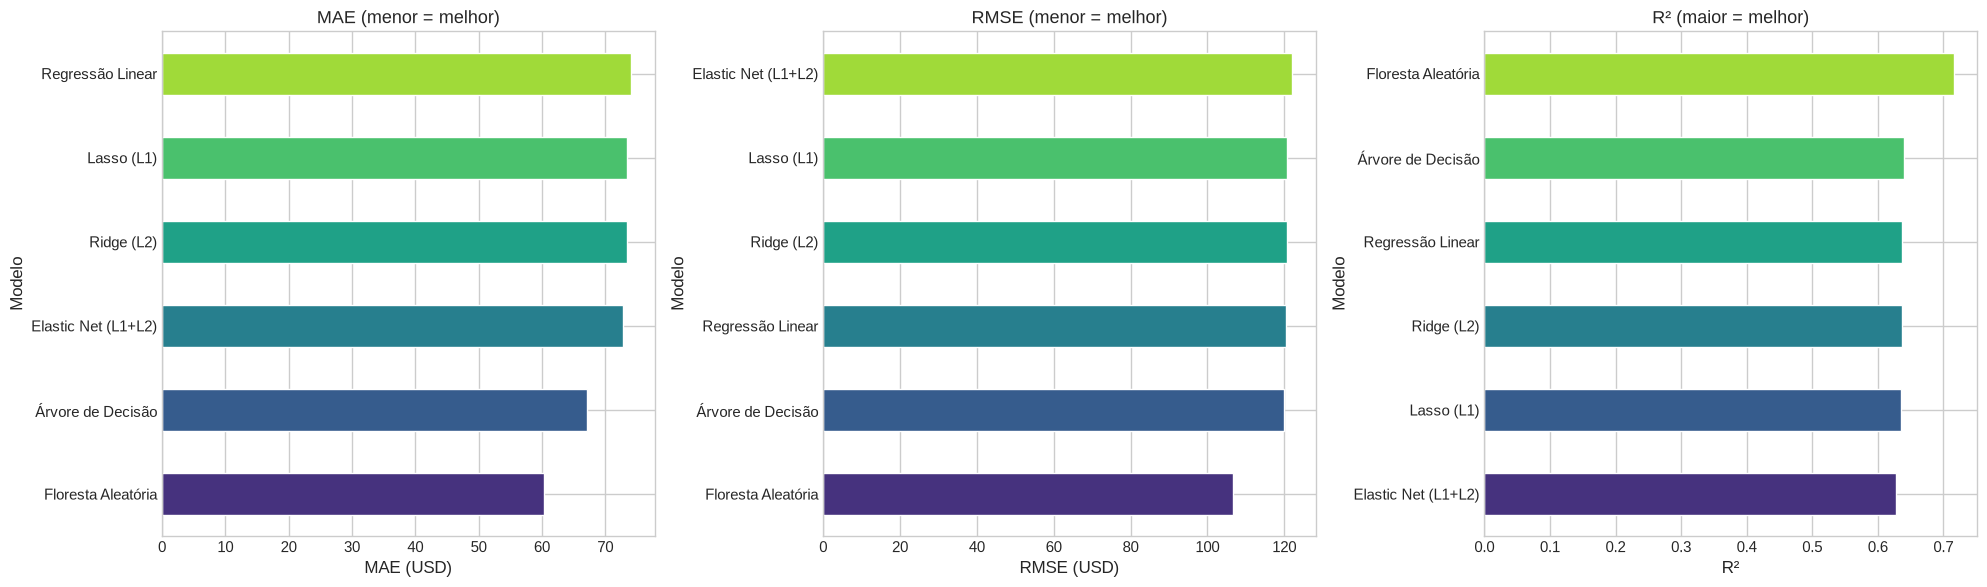

In [96]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = sns.color_palette('viridis', n_colors=len(resultados))

# MAE
resultados.sort_values('MAE (CV)').plot(
    x='Modelo', y='MAE (CV)', kind='barh', ax=axes[0],
    color=colors, legend=False, edgecolor='white'
)
axes[0].set_title('MAE (menor = melhor)', fontsize=13)
axes[0].set_xlabel('MAE (USD)')

# RMSE
resultados.sort_values('RMSE (CV)').plot(
    x='Modelo', y='RMSE (CV)', kind='barh', ax=axes[1],
    color=colors, legend=False, edgecolor='white'
)
axes[1].set_title('RMSE (menor = melhor)', fontsize=13)
axes[1].set_xlabel('RMSE (USD)')

# R²
resultados.sort_values('R² (CV)', ascending=True).plot(
    x='Modelo', y='R² (CV)', kind='barh', ax=axes[2],
    color=colors, legend=False, edgecolor='white'
)
axes[2].set_title('R² (maior = melhor)', fontsize=13)
axes[2].set_xlabel('R²')

plt.tight_layout()
plt.show()

---
## 10. Avaliação no Conjunto de Teste

Usamos o **melhor modelo** (menor MAE na validação cruzada) para avaliar no conjunto de teste — dados **nunca vistos** durante o treinamento.

In [97]:
# Selecionar o melhor modelo
melhor_nome = resultados.iloc[0]['Modelo']
print(f"🏆 Melhor modelo: {melhor_nome}")

modelos_dict = {
    'Regressão Linear': lr,
    'Árvore de Decisão': best_dt,
    'Floresta Aleatória': best_rf,
    'Ridge (L2)': best_ridge,
    'Lasso (L1)': best_lasso,
    'Elastic Net (L1+L2)': best_enet,
}

modelo_final = modelos_dict[melhor_nome]

# Previsões no conjunto de teste
y_pred_test = modelo_final.predict(X_test_prep)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"\n{'=' * 60}")
print(f"AVALIAÇÃO NO CONJUNTO DE TESTE (MÉTRICAS DE ERRO)")
print(f"{'=' * 60}")
print(f"MAE (Erro Médio Absoluto):         ${mae_test:.2f}")
print(f"RMSE (Raiz do Erro Quadrático):    ${rmse_test:.2f}")
print(f"MAPE (Erro Percentual Médio):      {mape_test:.2f}%")
print(f"R² (Coeficiente de Determinação):  {r2_test:.4f}")
print(f"\nInterpretação do Erro:")
print(f"  → O modelo erra em média ${mae_test:.2f} por noite na previsão do preço")
print(f"  → O erro percentual médio das previsões é de {mape_test:.1f}%")
print(f"  → O modelo explica {r2_test*100:.1f}% da variação dos preços em dados novos")

🏆 Melhor modelo: Floresta Aleatória

AVALIAÇÃO NO CONJUNTO DE TESTE
MAE:   $61.28
RMSE:  $109.16
R²:    0.7127

Interpretação:
  → O modelo erra em média $61.28 por noite na previsão do preço
  → O modelo explica 71.3% da variação dos preços


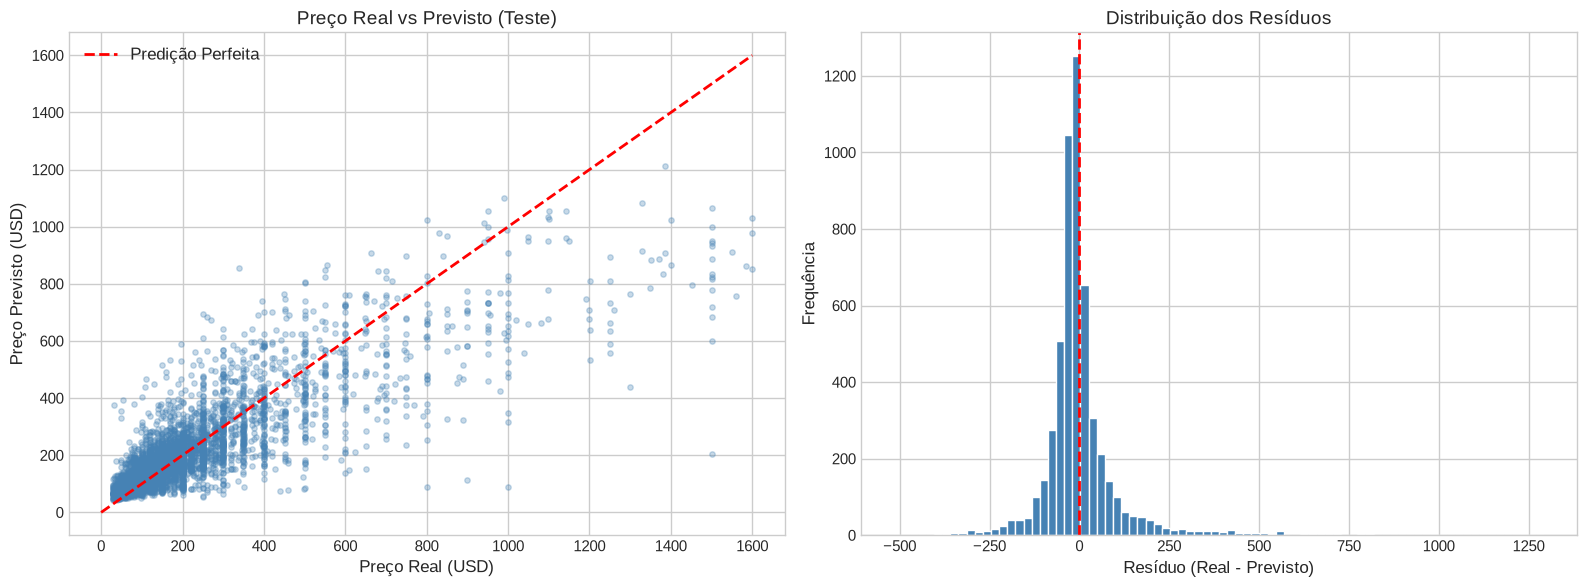

Resíduos — Média: 0.94, Mediana: -13.66


In [98]:
# Gráfico: Real vs Previsto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=15, c='steelblue')
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Predição Perfeita')
axes[0].set_xlabel('Preço Real (USD)', fontsize=12)
axes[0].set_ylabel('Preço Previsto (USD)', fontsize=12)
axes[0].set_title('Preço Real vs Previsto (Teste)', fontsize=14)
axes[0].legend(fontsize=12)

# Distribuição dos resíduos
residuos = y_test - y_pred_test
axes[1].hist(residuos, bins=80, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Resíduo (Real - Previsto)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_title('Distribuição dos Resíduos', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Resíduos — Média: {residuos.mean():.2f}, Mediana: {residuos.median():.2f}")

---
## 11. Importância das Variáveis

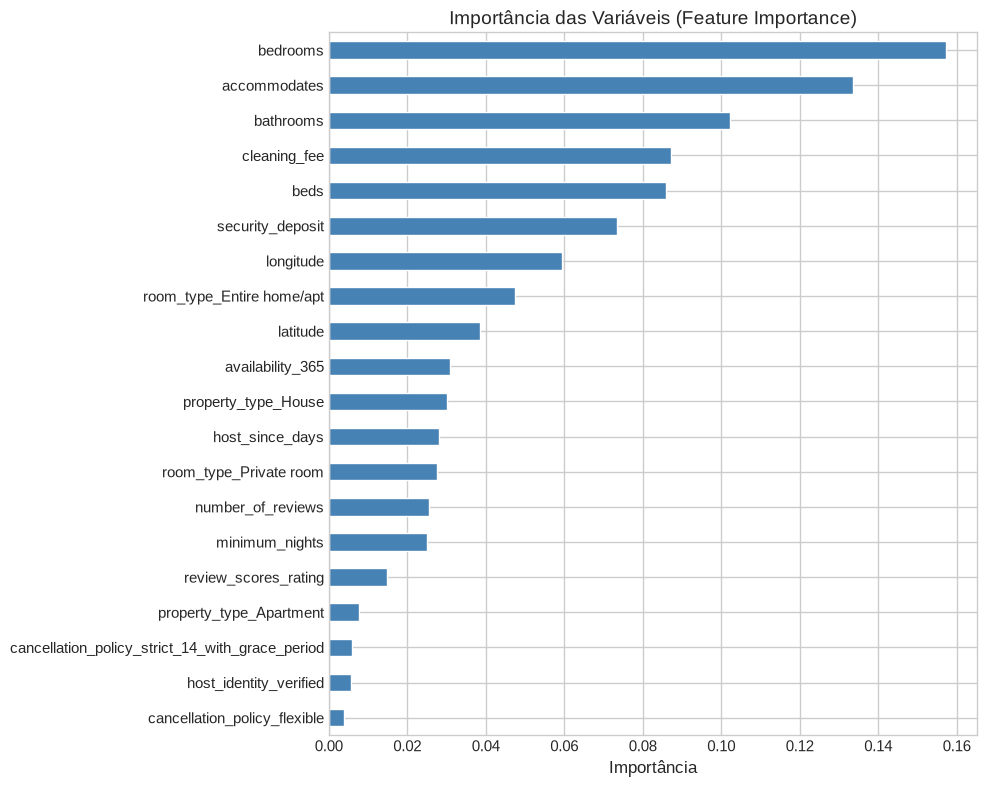


Top 20 features mais importantes:
   1. bedrooms                            → 0.1573
   2. accommodates                        → 0.1335
   3. bathrooms                           → 0.1021
   4. cleaning_fee                        → 0.0871
   5. beds                                → 0.0858
   6. security_deposit                    → 0.0734
   7. longitude                           → 0.0594
   8. room_type_Entire home/apt           → 0.0475
   9. latitude                            → 0.0384
  10. availability_365                    → 0.0309
  11. property_type_House                 → 0.0301
  12. host_since_days                     → 0.0280
  13. room_type_Private room              → 0.0275
  14. number_of_reviews                   → 0.0256
  15. minimum_nights                      → 0.0249
  16. review_scores_rating                → 0.0148
  17. property_type_Apartment             → 0.0077
  18. cancellation_policy_strict_14_with_grace_period → 0.0060
  19. host_identity_verified       

In [99]:
# Se o melhor modelo suporta feature_importances_ (árvore/floresta), usar diretamente
# Caso contrário, usar coeficientes absolutos

if hasattr(modelo_final, 'feature_importances_'):
    importancias = pd.Series(modelo_final.feature_importances_, index=all_feature_names)
    titulo = 'Importância das Variáveis (Feature Importance)'
elif hasattr(modelo_final, 'coef_'):
    importancias = pd.Series(np.abs(modelo_final.coef_), index=all_feature_names)
    titulo = 'Importância das Variáveis (|Coeficientes|)'
else:
    # Fallback: usar Random Forest para importância
    importancias = pd.Series(best_rf.feature_importances_, index=all_feature_names)
    titulo = 'Importância das Variáveis (Random Forest)'

importancias = importancias.sort_values(ascending=False)

# Top 20
top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
importancias.head(top_n).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(titulo, fontsize=14)
ax.set_xlabel('Importância')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features mais importantes:")
for i, (feat, imp) in enumerate(importancias.head(top_n).items(), 1):
    print(f"  {i:2d}. {feat:35s} → {imp:.4f}")

---
## 12. Aplicação Prática: Estimação do Preço Justo — Bondi Beach 🏖️

**Problema:** O anfitrião de Bondi Beach cobra atualmente **US\$ 500 por noite**.
Vamos usar o modelo final para estimar qual deveria ser o preço justo, dado o perfil do imóvel.

In [100]:
# Definir o novo imóvel de Bondi Beach
novo_imovel = pd.DataFrame([{
    # Geográficas
    "latitude": -33.889087,
    "longitude": 151.274506,
    # Anfitrião
    "host_is_superhost": 1,
    "host_identity_verified": 1,
    "host_listings_count": 1,
    "host_since_days": (data_ref - pd.Timestamp("2010-08-01")).days,
    # Imóvel
    "property_type": "House",
    "room_type": "Entire home/apt",
    "accommodates": 10,
    "bathrooms": 3.0,
    "bedrooms": 5.0,
    "beds": 7.0,
    # Taxas
    "security_deposit": 1500.0,
    "cleaning_fee": 370.0,
    "guests_included": 1,
    "total_extra_cost": 370.0 + 1500.0,
    # Regras
    "minimum_nights": 4,
    "cancellation_policy": "strict_14_with_grace_period",
    "instant_bookable": 0,
    # Disponibilidade
    "availability_365": 255,
    # Avaliações
    "number_of_reviews": 53,
    "review_scores_rating": 95.0,
    # Calculado
    "calculated_host_listings_count": 1,
}])

# Garantir que as colunas estejam na mesma ordem do treino
novo_imovel = novo_imovel.reindex(columns=X_train.columns)
print("Perfil do imóvel:")
print(novo_imovel.to_string())

Perfil do imóvel:
    longitude   latitude  review_scores_rating  number_of_reviews  minimum_nights  security_deposit  cleaning_fee  accommodates  bathrooms  bedrooms  beds property_type        room_type  availability_365  host_identity_verified  host_is_superhost          cancellation_policy  host_since_days
0  151.274506 -33.889087                  95.0                 53               4            1500.0         370.0            10        3.0       5.0   7.0         House  Entire home/apt               255                       1                  1  strict_14_with_grace_period             2722


In [104]:
# Aplicar o mesmo preprocessamento
novo_imovel_prep = preprocessor.transform(novo_imovel)

# Previsão
preco_previsto = modelo_final.predict(novo_imovel_prep)[0]

# Cálculos de erro e margens de incerteza
preco_cobrado = 500.0
diferenca = preco_cobrado - preco_previsto
erro_absoluto = abs(diferenca)
pct_dif_cobrado = (erro_absoluto / preco_cobrado) * 100
pct_dif_previsto = (erro_absoluto / preco_previsto) * 100
preco_min = preco_previsto - mae_test
preco_max = preco_previsto + mae_test

print("=" * 65)
print("🏖️  ESTIMATIVA DE PREÇO E ANÁLISE DE ERRO — BONDI BEACH")
print("=" * 65)
print(f"")
print(f"  Preço cobrado atualmente:          US$ {preco_cobrado:.2f} / noite")
print(f"  Preço justo estimado pelo modelo:  US$ {preco_previsto:.2f} / noite")
print(f"")
print("-" * 65)
print("  📊 ANÁLISE DE ERRO NO RESULTADO FINAL:")
print("-" * 65)
print(f"  • Erro absoluto de precificação:    US$ {erro_absoluto:.2f} / noite")
print(f"  • Erro percentual (vs cobrado):     {pct_dif_cobrado:.1f}%")
print(f"  • Erro percentual (vs estimado):    {pct_dif_previsto:.1f}%")
print(f"  • Margem de erro do modelo (MAE):   ± US$ {mae_test:.2f} / noite")
print(f"  • Intervalo plausível com erro:     [US$ {preco_min:.2f} — US$ {preco_max:.2f}]")
print("-" * 65)
print(f"")


🏖️  ESTIMATIVA DE PREÇO E ANÁLISE DE ERRO — BONDI BEACH

  Preço cobrado atualmente:          US$ 500.00 / noite
  Preço justo estimado pelo modelo:  US$ 744.34 / noite

-----------------------------------------------------------------
  📊 ANÁLISE DE ERRO NO RESULTADO FINAL:
-----------------------------------------------------------------
  • Erro absoluto de precificação:    US$ 244.34 / noite
  • Erro percentual (vs cobrado):     48.9%
  • Erro percentual (vs estimado):    32.8%
  • Margem de erro do modelo (MAE):   ± US$ 61.28 / noite
  • Intervalo plausível com erro:     [US$ 683.06 — US$ 805.62]
-----------------------------------------------------------------



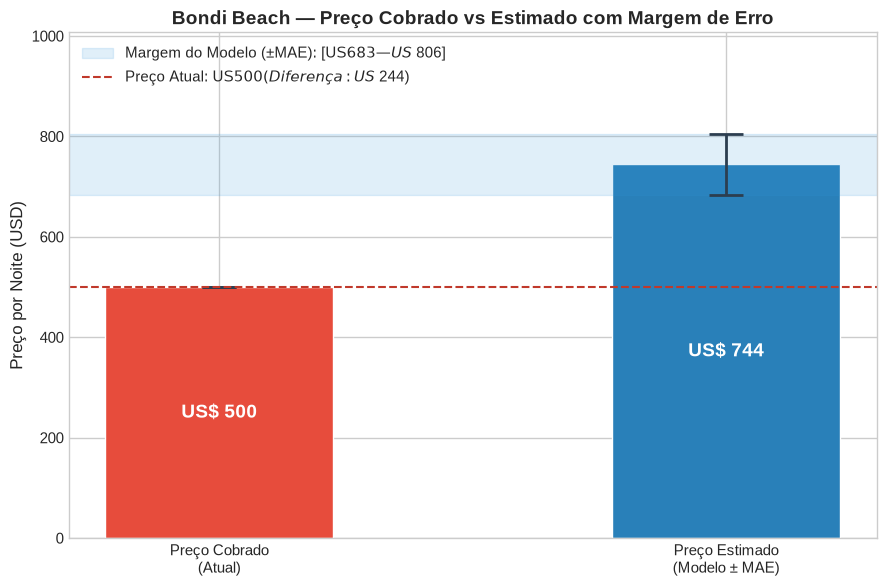

In [105]:
# Comparação visual: preço cobrado vs preço estimado com margem de erro
fig, ax = plt.subplots(figsize=(9, 6))

labels = ['Preço Cobrado\n(Atual)', f'Preço Estimado\n(Modelo ± MAE)']
valores = [preco_cobrado, preco_previsto]
erros = [0.0, mae_test]  # barra de erro correspondente ao MAE do modelo

bars = ax.bar(
    labels, valores,
    yerr=erros, capsize=12,
    color=['#e74c3c', '#2980b9'],
    edgecolor='white', width=0.45,
    error_kw={'elinewidth': 2, 'ecolor': '#2c3e50', 'capthick': 2}
)

# Adicionar valores nas barras
ax.text(bars[0].get_x() + bars[0].get_width() / 2, preco_cobrado / 2,
        f'US$ {preco_cobrado:.0f}', ha='center', va='center',
        fontsize=14, fontweight='bold', color='white')

ax.text(bars[1].get_x() + bars[1].get_width() / 2, preco_previsto / 2,
        f'US$ {preco_previsto:.0f}', ha='center', va='center',
        fontsize=14, fontweight='bold', color='white')

# Faixa de incerteza do modelo (intervalo plausível de preço)
ax.axhspan(preco_min, preco_max, color='#3498db', alpha=0.15,
           label=f'Margem do Modelo (±MAE): [US$ {preco_min:.0f} — US$ {preco_max:.0f}]')

# Linha de referência do preço cobrado
ax.axhline(preco_cobrado, color='#c0392b', linestyle='--', linewidth=1.5,
           label=f'Preço Atual: US$ {preco_cobrado:.0f} (Diferença: US$ {erro_absoluto:.0f})')

ax.set_ylabel('Preço por Noite (USD)', fontsize=12)
ax.set_title('Bondi Beach — Preço Cobrado vs Estimado com Margem de Erro', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(preco_cobrado, preco_max) * 1.25)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()